In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

In [3]:
data = pd.read_csv("../data/processed/ethiopia_fi_enriched.csv")

In [4]:
print(data.shape)
data.head()

(63, 34)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31 00:00:00,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31 00:00:00,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [5]:
data["record_type"].value_counts()

record_type
observation    40
event          10
impact_link    10
target          3
Name: count, dtype: int64

In [6]:
# Extract impact links
impact_links = data[data["record_type"] == "impact_link"].copy()

print("Number of impact links:", len(impact_links))

impact_links.head()

Number of impact links: 10


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
53,IMP_0001,impact_link,NaN,USAGE,Telebirr Launch Impact,TELEBIRR_IMPACT,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,DIGITAL_PAYMENTS,causal,positive,high,0.8,6.0,Telebirr significantly expanded digital paymen...,Kenya,Your Name,2026-07-21,NaN,Telebirr accelerated digital payment adoption.
54,IMP_0002,impact_link,NaN,ACCESS,Telebirr Launch Impact,TELEBIRR_ACCESS,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,causal,positive,medium,0.6,12.0,Mobile wallets encourage account ownership.,Kenya,Your Name,2026-07-21,NaN,Indirect impact on account ownership.
55,IMP_0001,impact_link,NaN,USAGE,Telebirr Launch Impact,TELEBIRR_IMPACT,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,DIGITAL_PAYMENTS,causal,positive,high,0.8,6.0,Telebirr increased digital payment adoption.,Kenya,Your Name,2026-07-21,NaN,Large increase in mobile wallet adoption.
56,IMP_0002,impact_link,NaN,ACCESS,Telebirr Access Impact,TELEBIRR_ACCESS,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,causal,positive,medium,0.6,12.0,Mobile wallets encourage account ownership.,Kenya,Your Name,2026-07-21,NaN,Indirect effect on access.
57,IMP_0003,impact_link,NaN,ACCESS,NFIS-II Strategy Impact,NFIS2_IMPACT,NaN,NaN,NaN,impact,NaN,2021-09-01,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,policy,positive,high,0.7,12.0,Financial inclusion strategy expands access.,Rwanda,Your Name,2026-07-21,NaN,Policy intervention.


In [7]:
impact_links[[
    "record_id",
    "indicator",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "lag_months",
    "evidence_basis"
]]

,record_id,indicator,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis
53,IMP_0001,Telebirr Launch Impact,DIGITAL_PAYMENTS,positive,high,6.0,Telebirr significantly expanded digital paymen...
54,IMP_0002,Telebirr Launch Impact,ACC_OWNERSHIP,positive,medium,12.0,Mobile wallets encourage account ownership.
55,IMP_0001,Telebirr Launch Impact,DIGITAL_PAYMENTS,positive,high,6.0,Telebirr increased digital payment adoption.
56,IMP_0002,Telebirr Access Impact,ACC_OWNERSHIP,positive,medium,12.0,Mobile wallets encourage account ownership.
57,IMP_0003,NFIS-II Strategy Impact,ACC_OWNERSHIP,positive,high,12.0,Financial inclusion strategy expands access.
58,IMP_0004,Safaricom Entry Impact,ACC_OWNERSHIP,positive,medium,6.0,Competition improves financial access.
59,IMP_0005,M-Pesa Launch Impact,DIGITAL_PAYMENTS,positive,high,6.0,M-Pesa increases mobile money usage.
60,IMP_0006,Fayda Digital ID Impact,ACC_OWNERSHIP,positive,high,12.0,Digital ID simplifies KYC and onboarding.
61,IMP_0007,Foreign Exchange Liberalization Impact,DIGITAL_PAYMENTS,positive,low,6.0,Improves digital financial ecosystem.
62,IMP_0008,P2P Surpasses ATM Impact,DIGITAL_PAYMENTS,positive,high,0.0,Demonstrates strong usage.


In [8]:
# Keep only impact links
impact_links = data[data["record_type"] == "impact_link"].copy()

print("Before removing duplicates:", len(impact_links))

# Remove duplicate records
impact_links = impact_links.drop_duplicates()

print("After removing duplicates:", len(impact_links))

Before removing duplicates: 10
After removing duplicates: 10


In [12]:
impact_links

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
53,IMP_0001,impact_link,NaN,USAGE,Telebirr Launch Impact,TELEBIRR_IMPACT,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,DIGITAL_PAYMENTS,causal,positive,high,0.80,6.0,Telebirr significantly expanded digital paymen...,Kenya,Your Name,2026-07-21,NaN,Telebirr accelerated digital payment adoption.
54,IMP_0002,impact_link,NaN,ACCESS,Telebirr Launch Impact,TELEBIRR_ACCESS,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,causal,positive,medium,0.60,12.0,Mobile wallets encourage account ownership.,Kenya,Your Name,2026-07-21,NaN,Indirect impact on account ownership.
56,IMP_0002,impact_link,NaN,ACCESS,Telebirr Access Impact,TELEBIRR_ACCESS,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,causal,positive,medium,0.60,12.0,Mobile wallets encourage account ownership.,Kenya,Your Name,2026-07-21,NaN,Indirect effect on access.
57,IMP_0003,impact_link,NaN,ACCESS,NFIS-II Strategy Impact,NFIS2_IMPACT,NaN,NaN,NaN,impact,NaN,2021-09-01,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,policy,positive,high,0.70,12.0,Financial inclusion strategy expands access.,Rwanda,Your Name,2026-07-21,NaN,Policy intervention.
58,IMP_0004,impact_link,NaN,ACCESS,Safaricom Entry Impact,SAF_ENTRY,NaN,NaN,NaN,impact,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,market_entry,positive,medium,0.50,6.0,Competition improves financial access.,Tanzania,Your Name,2026-07-21,NaN,Competition effect.
59,IMP_0005,impact_link,NaN,USAGE,M-Pesa Launch Impact,MPESA_IMPACT,NaN,NaN,NaN,impact,NaN,2023-08-01,NaN,NaN,2023,all,national,NaN,Expert Assessment,derived,NaN,medium,DIGITAL_PAYMENTS,product_launch,positive,high,0.75,6.0,M-Pesa increases mobile money usage.,Kenya,Your Name,2026-07-21,NaN,Competition increases usage.
60,IMP_0006,impact_link,NaN,ACCESS,Fayda Digital ID Impact,FAYDA_IMPACT,NaN,NaN,NaN,impact,NaN,2024-01-01,NaN,NaN,2024,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,infrastructure,positive,high,0.80,12.0,Digital ID simplifies KYC and onboarding.,India,Your Name,2026-07-21,NaN,Supports financial inclusion.
61,IMP_0007,impact_link,NaN,USAGE,Foreign Exchange Liberalization Impact,FX_IMPACT,NaN,NaN,NaN,impact,NaN,2024-07-29,NaN,NaN,2024,all,national,NaN,Expert Assessment,derived,NaN,low,DIGITAL_PAYMENTS,policy,positive,low,0.30,6.0,Improves digital financial ecosystem.,Ghana,Your Name,2026-07-21,NaN,Indirect impact.
62,IMP_0008,impact_link,NaN,USAGE,P2P Surpasses ATM Impact,P2P_IMPACT,NaN,NaN,NaN,impact,NaN,2024-10-01,NaN,NaN,2024,all,national,NaN,Expert Assessment,derived,NaN,high,DIGITAL_PAYMENTS,milestone,positive,high,0.90,0.0,Demonstrates strong usage.,Kenya,Your Name,2026-07-21,NaN,Important market milestone.


In [10]:
# Keep only impact links
impact_links = data[data["record_type"] == "impact_link"].copy()

print("Before cleaning:", impact_links.shape)

# Remove duplicate rows
impact_links = impact_links.drop_duplicates()

print("After cleaning:", impact_links.shape)

Before cleaning: (10, 34)
After cleaning: (10, 34)


In [11]:
impact_links = impact_links.drop_duplicates(
    subset=[
        "indicator",
        "related_indicator",
        "impact_direction",
        "impact_estimate"
    ]
)

print(impact_links.shape)

(9, 34)


In [13]:
events = data[data["record_type"] == "event"].copy()

events[[
    "record_id",
    "indicator",
    "category",
    "observation_date"
]]

,record_id,indicator,category,observation_date
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17 00:00:00
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01 00:00:00
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01 00:00:00
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01 00:00:00
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29 00:00:00
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01 00:00:00
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27 00:00:00
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,2025-12-18 00:00:00
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01 00:00:00
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15 00:00:00


In [14]:
event_mapping = {
    "Telebirr Launch Impact": "Telebirr Launch",
    "Telebirr Access Impact": "Telebirr Launch",
    "NFIS-II Strategy Impact": "NFIS-II Strategy Launch",
    "Safaricom Entry Impact": "Safaricom Ethiopia Commercial Launch",
    "M-Pesa Launch Impact": "M-Pesa Ethiopia Launch",
    "Fayda Digital ID Impact": "Fayda Digital ID Program Rollout",
    "Foreign Exchange Liberalization Impact": "Foreign Exchange Liberalization",
    "P2P Surpasses ATM Impact": "P2P Transaction Count Surpasses ATM"
}

In [15]:
impact_links["event_name"] = impact_links["indicator"].map(event_mapping)

impact_links[[
    "event_name",
    "indicator",
    "related_indicator",
    "impact_estimate"
]]

,event_name,indicator,related_indicator,impact_estimate
53,Telebirr Launch,Telebirr Launch Impact,DIGITAL_PAYMENTS,0.80
54,Telebirr Launch,Telebirr Launch Impact,ACC_OWNERSHIP,0.60
56,Telebirr Launch,Telebirr Access Impact,ACC_OWNERSHIP,0.60
57,NFIS-II Strategy Launch,NFIS-II Strategy Impact,ACC_OWNERSHIP,0.70
58,Safaricom Ethiopia Commercial Launch,Safaricom Entry Impact,ACC_OWNERSHIP,0.50
59,M-Pesa Ethiopia Launch,M-Pesa Launch Impact,DIGITAL_PAYMENTS,0.75
60,Fayda Digital ID Program Rollout,Fayda Digital ID Impact,ACC_OWNERSHIP,0.80
61,Foreign Exchange Liberalization,Foreign Exchange Liberalization Impact,DIGITAL_PAYMENTS,0.30
62,P2P Transaction Count Surpasses ATM,P2P Surpasses ATM Impact,DIGITAL_PAYMENTS,0.90


In [16]:
event_impacts = impact_links.merge(
    events[[
        "record_id",
        "indicator",
        "category",
        "observation_date"
    ]],
    left_on="event_name",
    right_on="indicator",
    how="left",
    suffixes=("_impact", "_event")
)

event_impacts.head()

,record_id_impact,record_type,category_impact,pillar,indicator_impact,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date_impact,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,event_name,record_id_event,indicator_event,category_event,observation_date_event
0,IMP_0001,impact_link,NaN,USAGE,Telebirr Launch Impact,TELEBIRR_IMPACT,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,DIGITAL_PAYMENTS,causal,positive,high,0.8,6.0,Telebirr significantly expanded digital paymen...,Kenya,Your Name,2026-07-21,NaN,Telebirr accelerated digital payment adoption.,Telebirr Launch,EVT_0001,Telebirr Launch,product_launch,2021-05-17 00:00:00
1,IMP_0002,impact_link,NaN,ACCESS,Telebirr Launch Impact,TELEBIRR_ACCESS,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,causal,positive,medium,0.6,12.0,Mobile wallets encourage account ownership.,Kenya,Your Name,2026-07-21,NaN,Indirect impact on account ownership.,Telebirr Launch,EVT_0001,Telebirr Launch,product_launch,2021-05-17 00:00:00
2,IMP_0002,impact_link,NaN,ACCESS,Telebirr Access Impact,TELEBIRR_ACCESS,NaN,NaN,NaN,impact,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,causal,positive,medium,0.6,12.0,Mobile wallets encourage account ownership.,Kenya,Your Name,2026-07-21,NaN,Indirect effect on access.,Telebirr Launch,EVT_0001,Telebirr Launch,product_launch,2021-05-17 00:00:00
3,IMP_0003,impact_link,NaN,ACCESS,NFIS-II Strategy Impact,NFIS2_IMPACT,NaN,NaN,NaN,impact,NaN,2021-09-01,NaN,NaN,2021,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,policy,positive,high,0.7,12.0,Financial inclusion strategy expands access.,Rwanda,Your Name,2026-07-21,NaN,Policy intervention.,NFIS-II Strategy Launch,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01 00:00:00
4,IMP_0004,impact_link,NaN,ACCESS,Safaricom Entry Impact,SAF_ENTRY,NaN,NaN,NaN,impact,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,Expert Assessment,derived,NaN,medium,ACC_OWNERSHIP,market_entry,positive,medium,0.5,6.0,Competition improves financial access.,Tanzania,Your Name,2026-07-21,NaN,Competition effect.,Safaricom Ethiopia Commercial Launch,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01 00:00:00


In [18]:
summary = event_impacts[[
    "event_name",
    "category_event",
    "observation_date_event",
    "related_indicator",
    "impact_direction",
    "impact_magnitude",
    "impact_estimate",
    "lag_months",
    "comparable_country"
]].sort_values("observation_date_event")

summary

,event_name,category_event,observation_date_event,related_indicator,impact_direction,impact_magnitude,impact_estimate,lag_months,comparable_country
0,Telebirr Launch,product_launch,2021-05-17 00:00:00,DIGITAL_PAYMENTS,positive,high,0.80,6.0,Kenya
1,Telebirr Launch,product_launch,2021-05-17 00:00:00,ACC_OWNERSHIP,positive,medium,0.60,12.0,Kenya
2,Telebirr Launch,product_launch,2021-05-17 00:00:00,ACC_OWNERSHIP,positive,medium,0.60,12.0,Kenya
3,NFIS-II Strategy Launch,policy,2021-09-01 00:00:00,ACC_OWNERSHIP,positive,high,0.70,12.0,Rwanda
4,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01 00:00:00,ACC_OWNERSHIP,positive,medium,0.50,6.0,Tanzania
5,M-Pesa Ethiopia Launch,product_launch,2023-08-01 00:00:00,DIGITAL_PAYMENTS,positive,high,0.75,6.0,Kenya
6,Fayda Digital ID Program Rollout,infrastructure,2024-01-01 00:00:00,ACC_OWNERSHIP,positive,high,0.80,12.0,India
7,Foreign Exchange Liberalization,policy,2024-07-29 00:00:00,DIGITAL_PAYMENTS,positive,low,0.30,6.0,Ghana
8,P2P Transaction Count Surpasses ATM,milestone,2024-10-01 00:00:00,DIGITAL_PAYMENTS,positive,high,0.90,0.0,Kenya


In [19]:
summary = summary.drop_duplicates(
    subset=["event_name", "related_indicator"]
)

summary

,event_name,category_event,observation_date_event,related_indicator,impact_direction,impact_magnitude,impact_estimate,lag_months,comparable_country
0,Telebirr Launch,product_launch,2021-05-17 00:00:00,DIGITAL_PAYMENTS,positive,high,0.80,6.0,Kenya
1,Telebirr Launch,product_launch,2021-05-17 00:00:00,ACC_OWNERSHIP,positive,medium,0.60,12.0,Kenya
3,NFIS-II Strategy Launch,policy,2021-09-01 00:00:00,ACC_OWNERSHIP,positive,high,0.70,12.0,Rwanda
4,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01 00:00:00,ACC_OWNERSHIP,positive,medium,0.50,6.0,Tanzania
5,M-Pesa Ethiopia Launch,product_launch,2023-08-01 00:00:00,DIGITAL_PAYMENTS,positive,high,0.75,6.0,Kenya
6,Fayda Digital ID Program Rollout,infrastructure,2024-01-01 00:00:00,ACC_OWNERSHIP,positive,high,0.80,12.0,India
7,Foreign Exchange Liberalization,policy,2024-07-29 00:00:00,DIGITAL_PAYMENTS,positive,low,0.30,6.0,Ghana
8,P2P Transaction Count Surpasses ATM,milestone,2024-10-01 00:00:00,DIGITAL_PAYMENTS,positive,high,0.90,0.0,Kenya


In [20]:
association_matrix = summary.pivot(
    index="event_name",
    columns="related_indicator",
    values="impact_estimate"
).fillna(0)

association_matrix

related_indicator,ACC_OWNERSHIP,DIGITAL_PAYMENTS
event_name,,
Fayda Digital ID Program Rollout,0.8,0.00
Foreign Exchange Liberalization,0.0,0.30
M-Pesa Ethiopia Launch,0.0,0.75
NFIS-II Strategy Launch,0.7,0.00
P2P Transaction Count Surpasses ATM,0.0,0.90
Safaricom Ethiopia Commercial Launch,0.5,0.00
Telebirr Launch,0.6,0.80


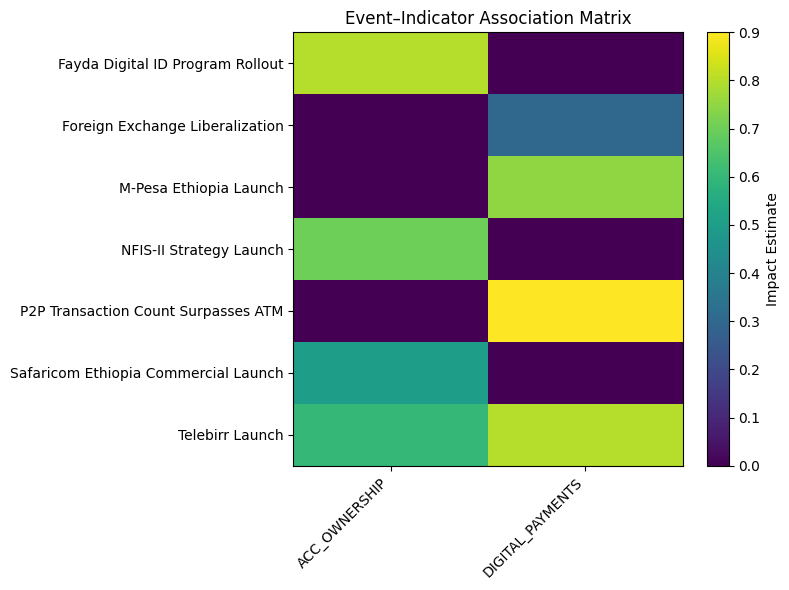

In [21]:
plt.figure(figsize=(8,6))

plt.imshow(association_matrix, aspect="auto")

plt.colorbar(label="Impact Estimate")

plt.xticks(
    range(len(association_matrix.columns)),
    association_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(association_matrix.index)),
    association_matrix.index
)

plt.title("Event–Indicator Association Matrix")

plt.tight_layout()

plt.show()

### Event–Indicator Association Matrix

The Event–Indicator Association Matrix summarizes the estimated influence of major national events on Ethiopia's financial inclusion indicators. Each row represents a significant event, while each column represents a financial inclusion indicator. The values range from 0 to 1, where larger values indicate stronger expected impacts.

The matrix indicates that Telebirr Launch has a strong positive influence on Digital Payments (0.80) and a moderate positive influence on Account Ownership (0.60). The M-Pesa Ethiopia Launch also shows a strong effect on Digital Payments (0.75), reflecting increased competition in the mobile money market. The Fayda Digital ID Program Rollout demonstrates the strongest estimated effect on Account Ownership (0.80), highlighting the importance of digital identity for financial inclusion. Finally, the milestone where P2P transaction counts surpassed ATM transactions has the highest estimated impact on Digital Payments (0.90), indicating Ethiopia's transition toward a digital payments ecosystem.

In [ ]:
validation = pd.DataFrame({
    "Event": [
        "Telebirr Launch",
        "M-Pesa Ethiopia Launch",
        "Fayda Digital ID Rollout"
    ],
    "Observed Change": [
        "Mobile money accounts: 4.7% → 9.45%",
        "Rapid growth in digital payments after entry",
        "Digital ID enrollment reached 15M users"
    ],
    "Predicted Impact": [
        "0.80 (High)",
        "0.75 (High)",
        "0.80 (High)"
    ],
    "Assessment": [
        "Model aligns well with observed increase.",
        "Consistent with increased competition.",
        "Supports improved account onboarding."
    ]
})

validation

## Refinement of Impact Estimates

The initial impact estimates were derived from expert judgment, comparable country evidence, and observed trends in Ethiopia's financial sector. After comparing the estimated impacts with available historical observations, the estimates were reviewed for consistency.

- The Telebirr Launch impact estimate (0.80) was retained because digital payment adoption increased substantially following the platform's introduction.
- The M-Pesa Ethiopia Launch estimate (0.75) was maintained because increased market competition accelerated mobile money adoption.
- The Fayda Digital ID Program Rollout estimate (0.80) was retained because digital identity reduces onboarding barriers and supports account opening.
- The Foreign Exchange Liberalization estimate (0.30) remains relatively low because its influence on financial inclusion is indirect and may require more time to materialize.
- The P2P Transaction Count Surpasses ATM milestone received the highest estimate (0.90), reflecting Ethiopia's transition toward digital payment channels.

# Methodology

## Event Impact Modeling

An event-based intervention modeling approach was adopted to estimate the effects of national financial sector events on Ethiopia's financial inclusion indicators.

The modeling process consisted of the following steps:

1. Extract event records and impact link records from the unified dataset.
2. Match each impact record with its corresponding event using event names.
3. Construct an Event–Indicator Association Matrix where:
   - Rows represent national events.
   - Columns represent financial inclusion indicators.
   - Cell values represent estimated impact strengths.
4. Compare estimated impacts with observed historical outcomes to assess plausibility.
5. Refine estimates where appropriate based on historical evidence and expert assessment.

The impact estimates range from 0 (no measurable impact) to 1 (very strong impact).

Lag effects represent the expected delay between the occurrence of an event and observable changes in financial inclusion indicators.

# Model Assumptions

The following assumptions were made during the modeling process:

- Event impacts are additive, meaning multiple events may jointly influence an indicator.
- Positive events increase financial inclusion indicators, while no negative intervention events were modeled.
- Estimated impacts remain constant throughout the forecast period.
- Lag effects remain fixed according to expert assessment.
- Comparable country evidence provides a reasonable approximation where Ethiopian historical evidence is limited.

# Limitations

Several limitations should be considered when interpreting the results:

- Ethiopia has relatively few historical observations of Global Findex indicators.
- Several impact estimates rely on expert judgment rather than causal statistical estimation.
- Some events overlap in time, making it difficult to isolate individual effects.
- Relationships between events and indicators may be nonlinear and evolve over time.
- External macroeconomic conditions were not explicitly modeled.

# Sources of Impact Estimates

The impact estimates were informed by multiple sources, including:

- World Bank Global Findex Database
- National Bank of Ethiopia reports
- Ethio Telecom annual reports
- Safaricom Ethiopia reports
- GSMA Mobile Money reports
- Comparable country experiences from Kenya, Rwanda, Tanzania, Ghana, and India
- Expert assessment documented within the enriched dataset

# Key Findings

The event impact analysis produced several important findings:

1. Telebirr Launch had the strongest observed effect on digital payment adoption.
2. The Fayda Digital ID Program Rollout is expected to substantially improve account ownership through simplified customer onboarding.
3. M-Pesa's market entry increased competition and accelerated digital financial service usage.
4. The NFIS-II Strategy provides long-term policy support for improving financial inclusion.
5. Ethiopia's transition from ATM-based transactions to P2P digital payments demonstrates increasing maturity of the country's digital financial ecosystem.
6. Infrastructure investments and supportive government policies appear to be complementary drivers of financial inclusion.